# Laboratorio: Deteccion de fraude con regresion logistica

Objetivo: entrenar un modelo de regresion logistica para clasificar transacciones como legitimas o fraudulentas usando el dataset descargado desde un bucket publico de AWS S3.

Metricas principales: precision, recall, F1 y matriz de confusion.

## 1. Configuracion e importaciones

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
MODEL_SAMPLE_SIZE = 500_000  # Cambia a None para entrenar con las 6,362,620 filas.
TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20

## 2. Carga de datos

In [2]:
# URL del archivo en el bucket publico de AWS
url = "https://hybridge-education-machine-learning-datasets.s3.us-east-1.amazonaws.com/Fraud.csv"
df = pd.read_csv(url)

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
display(df.head())

Filas: 6,362,620
Columnas: 11


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 3. Exploracion inicial

In [3]:
resumen = pd.DataFrame({
    "tipo_dato": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "valores_unicos": df.nunique(),
})
display(resumen)

distribucion_objetivo = (
    df["isFraud"]
    .value_counts(normalize=True)
    .rename(index={0: "Legitima", 1: "Fraudulenta"})
    .mul(100)
    .round(4)
)
display(distribucion_objetivo.to_frame("porcentaje"))

display(pd.crosstab(df["type"], df["isFraud"], margins=True))

,tipo_dato,nulos,valores_unicos
step,int64,0,743
type,str,0,5
amount,float64,0,5316900
nameOrig,str,0,6353307
oldbalanceOrg,float64,0,1845844
newbalanceOrig,float64,0,2682586
nameDest,str,0,2722362
oldbalanceDest,float64,0,3614697
newbalanceDest,float64,0,3555499
isFraud,int64,0,2


,porcentaje
isFraud,
Legitima,99.8709
Fraudulenta,0.1291


isFraud,0,1,All
type,,,
CASH_IN,1399284,0,1399284
CASH_OUT,2233384,4116,2237500
DEBIT,41432,0,41432
PAYMENT,2151495,0,2151495
TRANSFER,528812,4097,532909
All,6354407,8213,6362620


El dataset tiene 6,362,620 observaciones. La clase fraudulenta es muy minoritaria, por eso se usa separacion estratificada y `class_weight="balanced"` en el modelo.

## 4. Preprocesamiento y variables predictoras

In [4]:
def agregar_variables(data: pd.DataFrame) -> pd.DataFrame:
    """Agrega variables numericas simples sin usar identificadores de alta cardinalidad."""
    data = data.copy()
    data["error_saldo_origen"] = data["oldbalanceOrg"] - data["amount"] - data["newbalanceOrig"]
    data["error_saldo_destino"] = data["oldbalanceDest"] + data["amount"] - data["newbalanceDest"]
    data["monto_sobre_saldo_origen"] = data["amount"] / (data["oldbalanceOrg"] + 1)
    data["hora_aproximada"] = data["step"] % 24
    data["destino_es_comercio"] = data["nameDest"].str.startswith("M").astype(int)
    return data


df_features = agregar_variables(df)

columnas_a_eliminar = ["isFraud", "nameOrig", "nameDest"]
X = df_features.drop(columns=columnas_a_eliminar)
y = df_features["isFraud"]

columnas_categoricas = ["type"]
columnas_numericas = [col for col in X.columns if col not in columnas_categoricas]

print("Variables numericas:", columnas_numericas)
print("Variables categoricas:", columnas_categoricas)

Variables numericas: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'error_saldo_origen', 'error_saldo_destino', 'monto_sobre_saldo_origen', 'hora_aproximada', 'destino_es_comercio']
Variables categoricas: ['type']


Para que el entrenamiento sea viable en una laptop, se usa una muestra estratificada configurable. La proporcion de fraude se conserva en la muestra.

In [5]:
if MODEL_SAMPLE_SIZE is not None and MODEL_SAMPLE_SIZE < len(X):
    X_model, _, y_model, _ = train_test_split(
        X,
        y,
        train_size=MODEL_SAMPLE_SIZE,
        stratify=y,
        random_state=RANDOM_STATE,
    )
else:
    X_model, y_model = X, y

print(f"Filas usadas para modelado: {len(X_model):,}")
display(y_model.value_counts(normalize=True).rename(index={0: "Legitima", 1: "Fraudulenta"}).to_frame("proporcion"))

Filas usadas para modelado: 500,000


,proporcion
isFraud,
Legitima,0.99871
Fraudulenta,0.00129


In [6]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_model,
    y_model,
    test_size=TEST_SIZE,
    stratify=y_model,
    random_state=RANDOM_STATE,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=VALIDATION_SIZE,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

print(f"Entrenamiento: {len(X_train):,}")
print(f"Validacion: {len(X_val):,}")
print(f"Prueba: {len(X_test):,}")

Entrenamiento: 320,000
Validacion: 80,000
Prueba: 100,000


## 5. Entrenamiento del modelo

In [7]:
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocesador = ColumnTransformer(
    transformers=[
        ("numericas", StandardScaler(), columnas_numericas),
        ("categoricas", encoder, columnas_categoricas),
    ]
)

modelo = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador),
        (
            "regresion_logistica",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

modelo.fit(X_train, y_train)
print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## 6. Ajuste del umbral de decision

In [8]:
proba_val = modelo.predict_proba(X_val)[:, 1]
precision_val, recall_val, thresholds_val = precision_recall_curve(y_val, proba_val)

# F2 prioriza recall, importante cuando el costo de no detectar fraude es alto.
beta = 2
f2_scores = (1 + beta**2) * precision_val[:-1] * recall_val[:-1] / (
    beta**2 * precision_val[:-1] + recall_val[:-1] + 1e-12
)
mejor_indice = int(np.nanargmax(f2_scores))
mejor_umbral = float(thresholds_val[mejor_indice])

print(f"Mejor umbral segun F2 en validacion: {mejor_umbral:.4f}")
print(f"F2 de validacion: {f2_scores[mejor_indice]:.4f}")

Mejor umbral segun F2 en validacion: 0.9952
F2 de validacion: 0.6357


## 7. Evaluacion final

In [9]:
proba_test = modelo.predict_proba(X_test)[:, 1]
y_pred = (proba_test >= mejor_umbral).astype(int)

metricas_finales = pd.DataFrame(
    {
        "Metrica": ["Precision", "Recall", "F1", "ROC AUC", "Average Precision"],
        "Valor": [
            precision_score(y_test, y_pred, zero_division=0),
            recall_score(y_test, y_pred, zero_division=0),
            f1_score(y_test, y_pred, zero_division=0),
            roc_auc_score(y_test, proba_test),
            average_precision_score(y_test, proba_test),
        ],
    }
)

print("Reporte de clasificacion:")
print(classification_report(y_test, y_pred, target_names=["Legitima", "Fraudulenta"], zero_division=0))
display(metricas_finales.style.format({"Valor": "{:.4f}"}))
display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=["Real legitima", "Real fraudulenta"], columns=["Pred legitima", "Pred fraudulenta"]))

Reporte de clasificacion:
              precision    recall  f1-score   support

    Legitima       1.00      1.00      1.00     99871
 Fraudulenta       0.58      0.57      0.57       129

    accuracy                           1.00    100000
   macro avg       0.79      0.78      0.79    100000
weighted avg       1.00      1.00      1.00    100000



,Metrica,Valor
0,Precision,0.5794
1,Recall,0.5659
2,F1,0.5725
3,ROC AUC,0.9966
4,Average Precision,0.6309


,Pred legitima,Pred fraudulenta
Real legitima,99818,53
Real fraudulenta,56,73


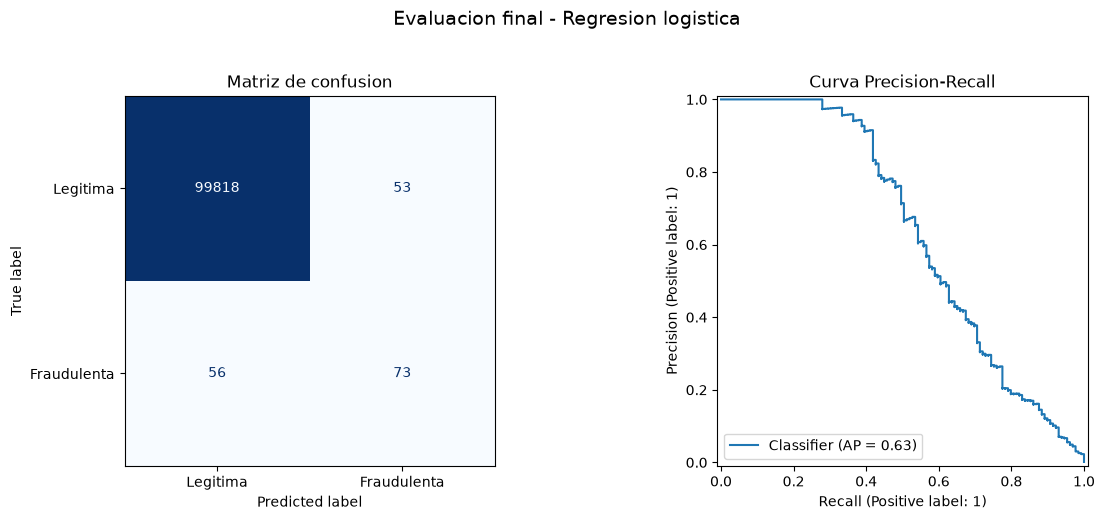

Imagen guardada en evaluacion_final.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Legitima", "Fraudulenta"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
    values_format="d",
)
axes[0].set_title("Matriz de confusion")

PrecisionRecallDisplay.from_predictions(y_test, proba_test, ax=axes[1])
axes[1].set_title("Curva Precision-Recall")

fig.suptitle("Evaluacion final - Regresion logistica", fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig("evaluacion_final.png", dpi=160, bbox_inches="tight")
plt.show()

print("Imagen guardada en evaluacion_final.png")

## 8. Conclusiones

- La regresion logistica permite construir un baseline interpretable para deteccion de fraude.
- Debido al desbalance extremo, recall y precision son mas informativas que accuracy.
- El uso de `class_weight="balanced"` y el ajuste del umbral ayudan a detectar mas transacciones fraudulentas.
- Para mejorar el modelo se podrian probar arboles, boosting, submuestreo/sobremuestreo y variables adicionales de comportamiento.